**Investments: Theory and Data Analysis**, Bates, Boyer, and Fletcher


# Example Chapter 11: The Efficient Frontier
In this example we provide a covariance matrix and vector of expected returns. The script then creates the efficient frontier of risky securities (EFRS), identifies the tangent portfolio, and creates a plot of both.  


### Imports and Setup

In [8]:
%pip install -q --upgrade farms
import farms as fm

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

Note: you may need to restart the kernel to use updated packages.


### Define Inputs
In the code cell below we define the covariance matrix and the vector of expected returns.  Here you can enter your own covriance matrix and vector of expected returns as desired, with any number of securities. You can also load these inputs from your account on Google Drive, or your own GitHub repo.   

In [9]:
covariance_matrix = np.array([[0.0400, -0.0200, 0.0250], [-0.0200, 0.0900, 0.0400], [0.0250, 0.0400, 0.2500]])
expected_returns = np.array([0.12, 0.06, 0.08])
rf = 0.05

### Developing the Grid of Target Returns
In the code cell below, we construct a grid of target expected returns. By default, the grid contains 100 equally spaced values, with the minimum set to half the smallest asset expected return and the maximum set to twice the largest asset expected return.

In [10]:
# Target returns
min_target = 0.5 * min(expected_returns)
max_target = 2 * max(expected_returns)
target_returns = np.linspace(min_target, max_target, num=100)

### Calculating Efficient Frontier with `farms.efrs_portfolio`

For full parameter details, see the [`farms` portfolio API documentation](https://github.com/boyerb/farms/blob/main/docs/api.md#efrs_portfolio--efrs_portfolio).

`efrs_portfolio()`

**Required Inputs**

- `target_return` — The target return for the efficient portfolio. Here it is each value in `target_returns`. Example: `target_return=target`.
- `expected_returns` — One-dimensional array of expected asset returns. Example: `expected_returns=expected_returns`.
- `covariance_matrix` — Covariance matrix with one row and column per asset. Example: `covariance_matrix=covariance_matrix`.

**Optional Inputs**

- `allow_short` — Default is `True`. Allows short positions, which lets this example evaluate targets outside the range of individual asset returns. Potential values are `True` and `False`. Example: `allow_short=False`.

**Outputs**

- `tuple` — Returns `(weights, expected_return, volatility)` for the minimum-variance portfolio at the target return. Example: `results=fm.efrs_portfolio(...)`.

In [11]:
# For every element in target_returns, identify the corresponding point on the EFRS
results = [fm.efrs_portfolio(target, expected_returns, covariance_matrix) for target in target_returns]

# store the results in numpy arrays
EFRS_weights = np.array([res[0] for res in results])
EFRS_returns = np.array([res[1] for res in results])
EFRS_volatilities = np.array([res[2] for res in results])


### Define the Tangent Portfolio
For full parameter details, see the [`farms` portfolio API documentation](https://github.com/boyerb/farms/blob/main/docs/api.md#tangent_portfolio).

`tangent_portfolio()`

**Required Inputs**

- `expected_returns` — One-dimensional array of expected asset returns. Example: `expected_returns=expected_returns`.
- `covariance_matrix` — Asset covariance matrix in the same order as `expected_returns`. Example: `covariance_matrix=covariance_matrix`.

**Optional Inputs**

- `rf` — Default is `0.0`. Risk-free return used in the Sharpe-ratio objective. Example: `rf=rf`.

**Outputs**

- `tuple` — Returns `(exposures, expected_return, volatility)`. `exposures` are the fully invested tangent-portfolio weights. Example: `tangent_weights, tangent_return, tangent_volatility = fm.tangent_portfolio(...)`.

In [12]:
tangent_weights, tangent_return, tangent_volatility = fm.tangent_portfolio(expected_returns, covariance_matrix, rf=rf)

In [13]:
print("tangent_weights:", tangent_weights)

tangent_weights: [ 0.82093534  0.25849221 -0.07942754]


### Plot the EFRS, Efficient Frontier, and Tangent Portfolio
The code below plots the efficient frontier of risky securities (EFRS) and the efficient frontier which is the CAL of the tangent portfolio. The tangent portfolio itself is marked with a red star.


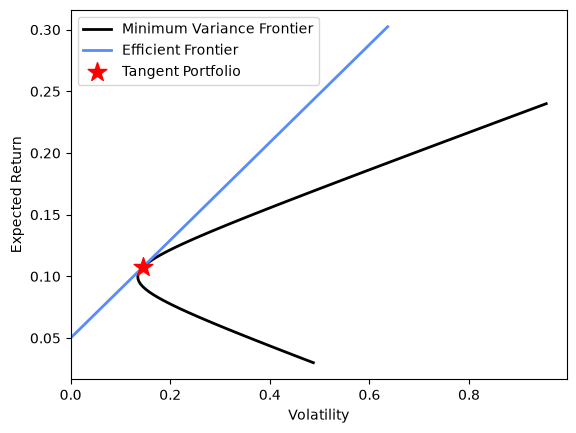

In [14]:
plt.plot(EFRS_volatilities, EFRS_returns, label="Minimum Variance Frontier", linewidth=2, color="k", zorder=1)
plt.xlim(0)
# plt.axhline(y=0, color="k")
plt.xlabel("Volatility")
plt.ylabel("Expected Return")

max_sharpe = (tangent_return - rf) / tangent_volatility

# create two volatility values for the efficient-frontier line:
x = np.array([0, max(EFRS_volatilities) * 2 / 3])  # Volatility range
y = np.array([rf, x[1] * max_sharpe + rf])  # Corresponding returns

plt.plot(x, y, label="Efficient Frontier", linewidth=2, zorder=2)
plt.scatter(tangent_volatility, tangent_return, color="r", marker="*", s=200, label="Tangent Portfolio", zorder=3, )
plt.legend(loc="upper left")
plt.show()
